In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder

In [2]:
data = pd.read_csv('Cardetails.csv')

# EDA(Exploratory Data Analysis)

In [3]:
data.head()     # data preview

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.4 kmpl,1248 CC,74 bhp,190Nm@ 2000rpm,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14 kmpl,1498 CC,103.52 bhp,250Nm@ 1500-2500rpm,5.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.7 kmpl,1497 CC,78 bhp,"12.7@ 2,700(kgm@ rpm)",5.0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.0 kmpl,1396 CC,90 bhp,22.4 kgm at 1750-2750rpm,5.0
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.1 kmpl,1298 CC,88.2 bhp,"11.5@ 4,500(kgm@ rpm)",5.0


In [4]:
data.shape      # rows & columns

(8128, 13)

In [5]:
data.info()     # data types

<class 'pandas.DataFrame'>
RangeIndex: 8128 entries, 0 to 8127
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   name           8128 non-null   str    
 1   year           8128 non-null   int64  
 2   selling_price  8128 non-null   int64  
 3   km_driven      8128 non-null   int64  
 4   fuel           8128 non-null   str    
 5   seller_type    8128 non-null   str    
 6   transmission   8128 non-null   str    
 7   owner          8128 non-null   str    
 8   mileage        7907 non-null   str    
 9   engine         7907 non-null   str    
 10  max_power      7913 non-null   str    
 11  torque         7906 non-null   str    
 12  seats          7907 non-null   float64
dtypes: float64(1), int64(3), str(9)
memory usage: 1.6 MB


In [6]:
data.isnull().sum()     # null check

name               0
year               0
selling_price      0
km_driven          0
fuel               0
seller_type        0
transmission       0
owner              0
mileage          221
engine           221
max_power        215
torque           222
seats            221
dtype: int64

In [7]:
for col in data.columns:
    print(col, ":", data[col].nunique())

name : 2058
year : 29
selling_price : 677
km_driven : 921
fuel : 4
seller_type : 3
transmission : 2
owner : 5
mileage : 393
engine : 121
max_power : 322
torque : 441
seats : 9


# Data Preprocessing

In [8]:
# Drop unnecessary columns
data.drop(columns=['torque'], inplace=True, errors='ignore')

In [9]:
# Remove null values
data.dropna(inplace=True)

In [10]:
# Remove duplicates
data.drop_duplicates(inplace=True)

In [11]:
data.head(1)

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.4 kmpl,1248 CC,74 bhp,5.0


In [12]:
# Car Name
name_le = LabelEncoder()
data['name'] = name_le.fit_transform(data['name'])
# Fuel
fuel_le = LabelEncoder()
data['fuel'] = fuel_le.fit_transform(data['fuel'])
# seller type
seller_type_le = LabelEncoder()
data['seller_type'] = seller_type_le.fit_transform(data['seller_type'])
# Transmission
transmission_le = LabelEncoder()
data['transmission'] = transmission_le.fit_transform(data['transmission'])
# owner
owner_le = LabelEncoder()
data['owner'] = owner_le.fit_transform(data['owner'])
# mileage
data['mileage'] = data['mileage'].str.extract(r'(\d+\.?\d*)').astype(float)
data['mileage'].fillna(data['mileage'].mean(), inplace=True)
# engine
data['engine'] = data['engine'].str.extract(r'(\d+)').astype(float)
data['engine'].fillna(data['engine'].mean(), inplace=True)
# max_power
data['max_power'] = data['max_power'].str.extract(r'(\d+\.?\d*)').astype(float)
data['max_power'].fillna(data['max_power'].mean(), inplace=True)

C:\Users\NET LINK\AppData\Local\Temp\ipykernel_11004\950925097.py:18: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  data['mileage'].fillna(data['mileage'].mean(), inplace=True)
C:\Users\NET LINK\AppData\Local\Temp\ipykernel_11004\950925097.py:21: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through 

0        74.00
1       103.52
2        78.00
3        90.00
4        88.20
         ...  
8121     67.10
8122     88.73
8123     82.85
8124    110.00
8125     73.90
Name: max_power, Length: 6718, dtype: float64

In [13]:
data.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,seats
0,1250,2014,450000,145500,1,1,1,0,23.40,1248.0,74.00,5.0
1,1547,2014,370000,120000,1,1,1,2,21.14,1498.0,103.52,5.0
2,375,2006,158000,140000,3,1,1,4,17.70,1497.0,78.00,5.0
3,743,2010,225000,127000,1,1,1,0,23.00,1396.0,90.00,5.0
4,1291,2007,130000,120000,3,1,1,0,16.10,1298.0,88.20,5.0


In [14]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
numerical_cols = ['year', 'km_driven', 'mileage', 'engine', 'max_power', 'seats']
data[numerical_cols] = pd.DataFrame(scaler.fit_transform(data[numerical_cols]), columns=numerical_cols, index=data.index)

data.dropna(inplace=True)

In [15]:
inplace = True

# Data Analysis

In [16]:
data.describe()   # statistical summary

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,seats
count,6717.000000,6717.000000,6.717000e+03,6717.000000,6717.000000,6717.000000,6717.000000,6717.000000,6717.000000,6717.000000,6.717000e+03,6717.000000
mean,1007.877475,0.000519,5.263860e+05,-0.000067,1.882835,0.904868,0.914396,0.881048,0.000315,0.000192,-2.496473e-16,-0.000388
std,515.912208,0.999242,5.235504e+05,1.000134,1.001993,0.306814,0.279799,1.245956,0.999816,1.000026,1.000074e+00,0.999643
min,0.000000,-5.027516,2.999900e+04,-1.250545,0.000000,0.000000,0.000000,0.000000,-4.807616,-1.635182,-1.732733e+00,-3.489946
25%,598.000000,-0.668941,2.500000e+05,-0.603152,1.000000,1.000000,1.000000,0.000000,-0.658288,-0.473986,-6.514713e-01,-0.441650
50%,1048.000000,0.100219,4.200000e+05,-0.088581,1.000000,1.000000,1.000000,0.000000,-0.006251,-0.370633,-1.871277e-01,-0.441650
75%,1350.000000,0.869379,6.500000e+05,0.453148,3.000000,1.000000,1.000000,2.000000,0.749519,0.135997,3.856574e-01,-0.441650
max,1982.000000,1.638540,1.000000e+07,38.964781,3.000000,2.000000,1.000000,4.000000,5.565704,4.403850,9.842759e+00,8.703237


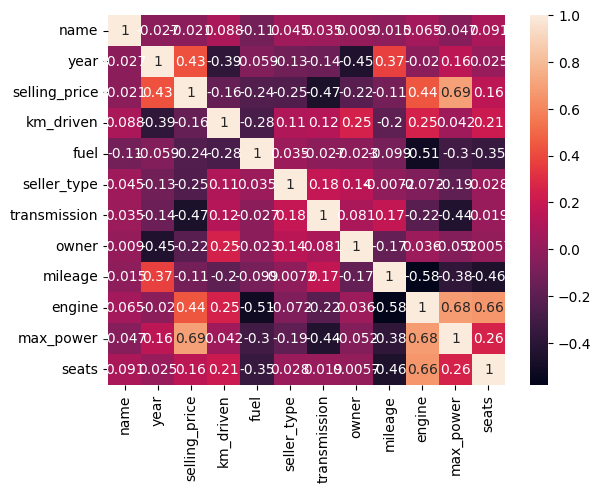

In [17]:
sns.heatmap(data.corr(), annot=True)
plt.show()

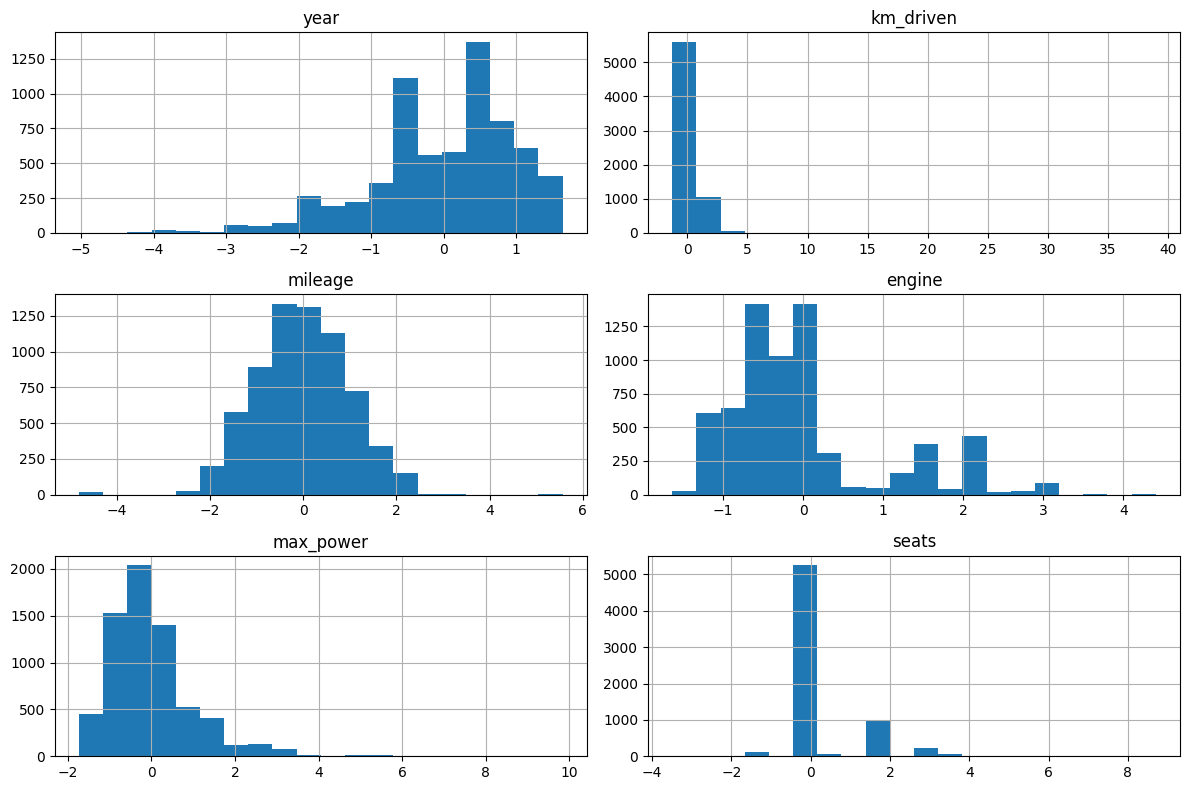

In [18]:
data[numerical_cols].hist(figsize=(12, 8), bins=20)
plt.tight_layout()
plt.show()

# Train Test split

In [19]:
X = data.drop("selling_price", axis=1)
Y = data["selling_price"]

In [20]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

In [21]:
model = LinearRegression()
model.fit(X_train, Y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [22]:
rf_model = RandomForestRegressor(random_state=42)
rf_model.fit(X_train, Y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [23]:
print("Train data X :", len(X_train))
print("Test data X :", len(X_test))
print("Train data Y :", len(Y_train))
print("Test data Y :", len(Y_test))

print("Linear Regression Test Score:", model.score(X_test, Y_test)*100)
print("Linear Regression Train Score:", model.score(X_train, Y_train)*100)

print("Random Forest Test Score:", rf_model.score(X_test, Y_test)*100)
print("Random Forest Train Score:", rf_model.score(X_train, Y_train)*100)

Train data X : 5373
Test data X : 1344
Train data Y : 5373
Test data Y : 1344
Linear Regression Test Score: 65.9518681428578
Linear Regression Train Score: 61.237440230044385
Random Forest Test Score: 92.42800071915063
Random Forest Train Score: 98.66532849227481


# Predicting Values From model using Random Forest Regressor in dataset

In [24]:
# using Row 2 of X_test and Y_test for prediction
rf_model.predict([[1314,0.869379,-0.988515,1,1,1,0,1.194090,-0.370633,0.023135,-0.441650]])

C:\Users\NET LINK\AppData\Roaming\Python\Python314\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


array([790479.99])

In [25]:
Y_test

7039     450000
5031     800000
2807      75000
1834    3200000
4945    1650000
         ...   
5173     325000
462      600000
1931     300000
1673    1300000
962      305000
Name: selling_price, Length: 1344, dtype: int64

In [26]:
X_test

,name,year,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,seats
7039,68,0.356606,1.390188,1,1,0,0,-1.149786,1.149258,2.393715,-0.441650
5031,1314,0.869379,-0.988515,1,1,1,0,1.194090,-0.370633,0.023135,-0.441650
2807,1606,-0.412554,-1.046117,3,1,1,0,-0.648409,-0.482092,-0.736585,-0.441650
1834,1844,1.125766,-0.228336,1,1,0,0,-1.092980,2.683334,2.734171,1.590547
4945,760,0.869379,-0.072907,1,0,1,0,-0.584193,1.064144,2.592314,-0.441650
...,...,...,...,...,...,...,...,...,...,...,...
5173,330,-0.156168,0.453148,1,1,1,0,1.564566,0.135997,0.341524,-0.441650
462,734,0.356606,-0.654264,3,1,1,0,-0.213717,-0.473986,-0.187128,-0.441650
1931,485,0.869379,-0.228336,3,1,1,0,0.206155,-0.877263,-0.621524,-0.441650
1673,475,0.356606,-0.432781,1,1,1,2,0.050555,0.306225,1.211578,-0.441650


# Predicting Values From model

In [27]:
new_data = pd.DataFrame([["Skoda Rapid 1.5 TDI Ambition",2014,120000,"Diesel","Individual","Manual","Second Owner","21.14 kmpl","1498 CC","103.52 bhp",5]], columns=X_train.columns)
new_data

,name,year,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,seats
0,Skoda Rapid 1.5 TDI Ambition,2014,120000,Diesel,Individual,Manual,Second Owner,21.14 kmpl,1498 CC,103.52 bhp,5


In [28]:
# Car Name
new_data['name'] = name_le.transform(new_data['name'])
# fuel
new_data['fuel'] = fuel_le.transform(new_data['fuel'])
# seller type
new_data['seller_type'] = seller_type_le.transform(new_data['seller_type'])
# transmission
new_data['transmission'] = transmission_le.transform(new_data['transmission'])
# owner
new_data['owner'] = owner_le.transform(new_data['owner'])
# mileage
new_data['mileage'] = new_data['mileage'].str.extract(r'(\d+\.?\d*)').astype(float)
# engine
new_data['engine'] = new_data['engine'].str.extract(r'(\d+)').astype(float)
# max_power
new_data['max_power'] = new_data['max_power'].str.extract(r'(\d+\.?\d*)').astype(float)

In [29]:
new_data[numerical_cols] = scaler.transform(new_data[numerical_cols])

In [30]:
rf_model.predict(new_data)

array([438319.99])